In [1]:
import numpy as np                                        # numerical computing library for matrix operations
import matplotlib.pyplot as plt                           # plotting library for displaying images and graphs
import os                                                 # operating system interface for file/path operations
from skimage.metrics import peak_signal_noise_ratio as psnr  # import PSNR function and alias it as 'psnr' for convenience
from skimage import data                                  # built-in image dataset from scikit-image
from PIL import Image                                     # Python Imaging Library for image handling

In [2]:
# ================== Helper Functions ==================

def compression_ratio(shape, k):
    m, n = shape                        # unpack image dimensions: m = rows, n = columns
    original = m * n                    # total pixels in original image
    compressed = k * (m + n + 1)       # storage needed for SVD components: U(m×k) + s(k) + Vt(k×n)
    return original / compressed        # ratio > 1 means compression was achieved

def compute_psnr(original, reconstructed):
    orig = np.clip(original, 0, 255).astype(np.uint8)          # clip pixel values to valid range [0,255] and convert to uint8
    recon = np.clip(reconstructed, 0, 255).astype(np.uint8)    # same clipping for reconstructed image to ensure valid comparison
    return psnr(orig, recon, data_range=255)                    # compute PSNR score; higher = better quality (data_range=255 for 8-bit images)

def svd_compress(img, k):
    U, s, Vt = np.linalg.svd(img, full_matrices=False)   # decompose image into U (left singular vectors), s (singular values), Vt (right singular vectors)
    return U[:, :k] @ np.diag(s[:k]) @ Vt[:k, :]         # reconstruct using only top-k singular values (matrix multiplication to rebuild approximation)

def display_image(img_array, title='', cmap='gray'):
    plt.figure(figsize=(4,4))        # create a new figure with 4x4 inch size
    plt.imshow(img_array, cmap=cmap) # display the image array using grayscale colormap
    plt.title(title)                 # set the title above the image
    plt.axis('off')                  # hide axis ticks and labels for cleaner display
    plt.show()                       # render and show the figure

In [3]:
# ================== Load Dataset ==================

print("📦 Loading built-in dataset...")   # inform user that loading has started

dataset = {
    'camera': data.camera(),  # grayscale image of a cameraman (512x512) - classic benchmark image
    'coins':  data.coins(),   # grayscale image of coins (303x384) - good for testing edge detail
    'moon':   data.moon(),    # grayscale image of the moon (400x400) - low contrast, smooth regions
    'clock':  data.clock(),   # grayscale image of a clock (300x400) - strong geometric features
    'page':   data.page()     # grayscale image of a text page (191x384) - high frequency content
}

📦 Loading built-in dataset...



🔧 Processing images...


--- camera ---
k=  5 | CR=51.15 | PSNR=20.00 dB
k= 10 | CR=25.58 | PSNR=22.11 dB
k= 20 | CR=12.79 | PSNR=24.62 dB
k= 30 | CR=8.53 | PSNR=26.33 dB
k= 50 | CR=5.12 | PSNR=28.63 dB
k= 75 | CR=3.41 | PSNR=30.94 dB
k=100 | CR=2.56 | PSNR=32.77 dB
k=150 | CR=1.71 | PSNR=36.14 dB
k=200 | CR=1.28 | PSNR=39.56 dB
k=512 | CR=0.50 | PSNR=51.38 dB


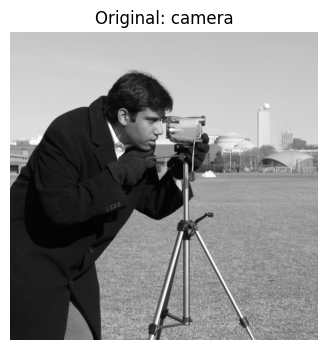

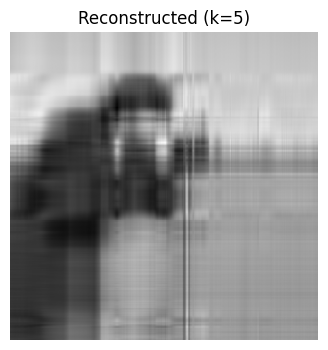

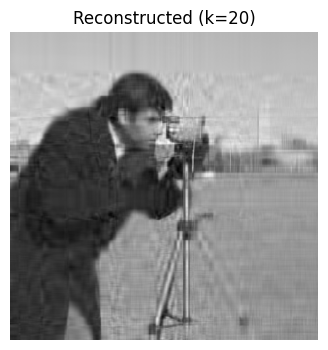

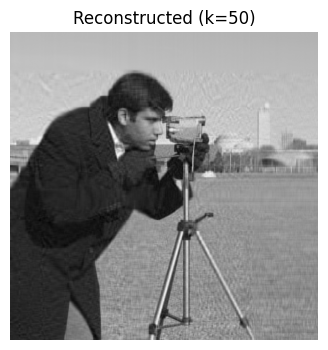

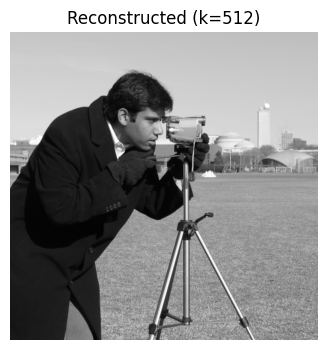


--- coins ---
k=  5 | CR=33.82 | PSNR=19.72 dB
k= 10 | CR=16.91 | PSNR=21.65 dB
k= 20 | CR=8.46 | PSNR=23.93 dB
k= 30 | CR=5.64 | PSNR=25.70 dB
k= 50 | CR=3.38 | PSNR=28.42 dB
k= 75 | CR=2.25 | PSNR=31.22 dB
k=100 | CR=1.69 | PSNR=33.81 dB
k=150 | CR=1.13 | PSNR=39.04 dB
k=200 | CR=0.85 | PSNR=44.90 dB
k=303 | CR=0.56 | PSNR=51.33 dB


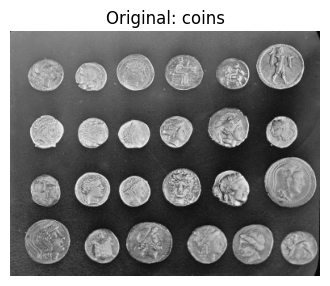

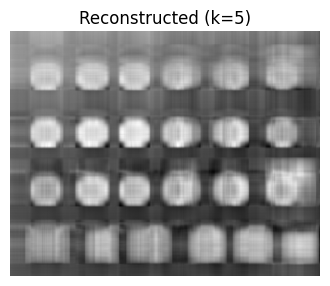

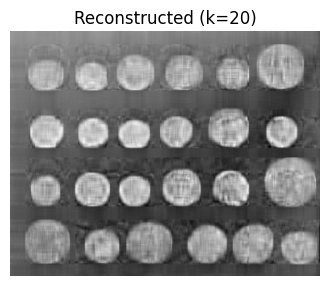

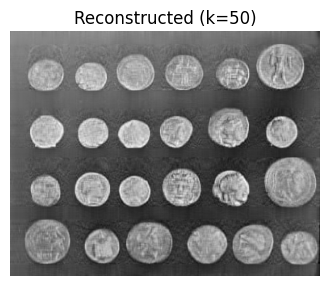

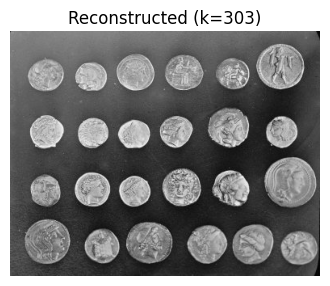


--- moon ---
k=  5 | CR=51.15 | PSNR=32.10 dB
k= 10 | CR=25.58 | PSNR=34.21 dB
k= 20 | CR=12.79 | PSNR=36.81 dB
k= 30 | CR=8.53 | PSNR=38.52 dB
k= 50 | CR=5.12 | PSNR=41.12 dB
k= 75 | CR=3.41 | PSNR=43.70 dB
k=100 | CR=2.56 | PSNR=45.99 dB
k=150 | CR=1.71 | PSNR=49.90 dB
k=200 | CR=1.28 | PSNR=51.14 dB
k=512 | CR=0.50 | PSNR=51.55 dB


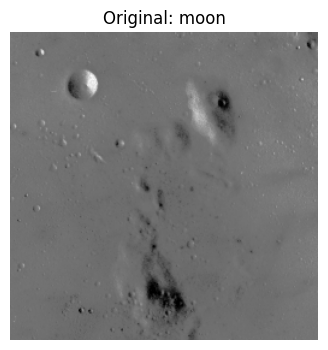

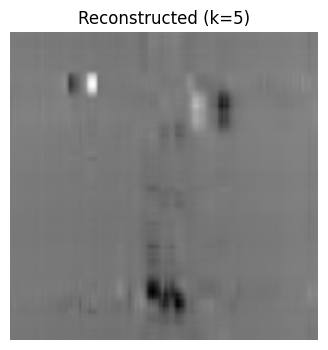

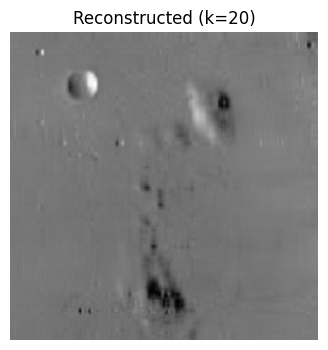

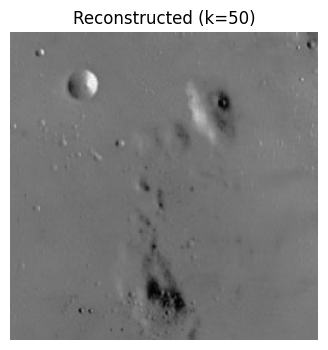

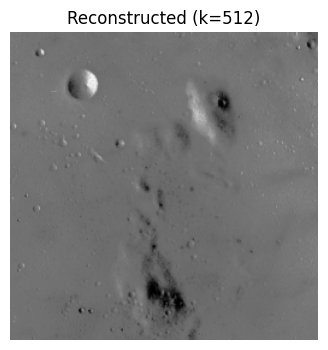


--- clock ---
k=  5 | CR=34.24 | PSNR=41.86 dB
k= 10 | CR=17.12 | PSNR=45.79 dB
k= 20 | CR=8.56 | PSNR=47.39 dB
k= 30 | CR=5.71 | PSNR=47.86 dB
k= 50 | CR=3.42 | PSNR=48.56 dB
k= 75 | CR=2.28 | PSNR=49.34 dB
k=100 | CR=1.71 | PSNR=50.04 dB
k=150 | CR=1.14 | PSNR=50.97 dB
k=200 | CR=0.86 | PSNR=51.14 dB
k=300 | CR=0.57 | PSNR=51.66 dB


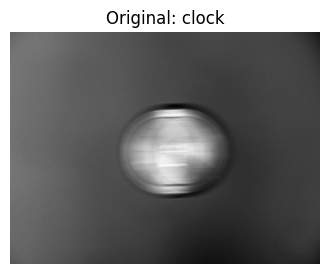

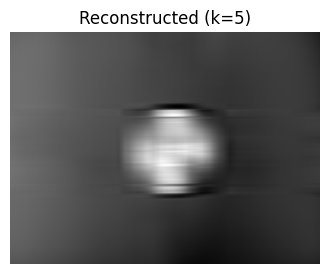

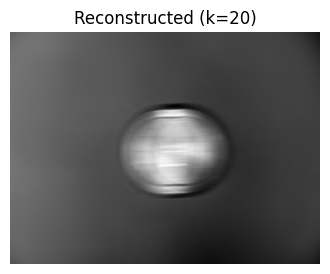

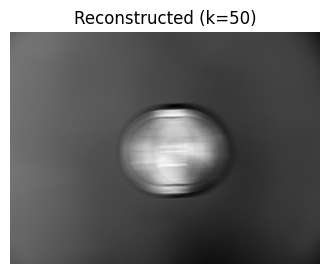

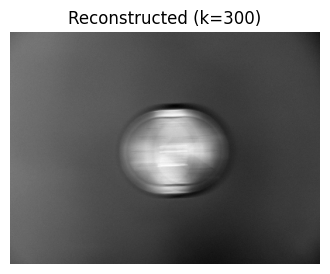


--- page ---
k=  5 | CR=25.47 | PSNR=19.64 dB
k= 10 | CR=12.73 | PSNR=21.57 dB
k= 20 | CR=6.37 | PSNR=23.97 dB
k= 30 | CR=4.24 | PSNR=26.19 dB
k= 50 | CR=2.55 | PSNR=30.72 dB
k= 75 | CR=1.70 | PSNR=35.90 dB
k=100 | CR=1.27 | PSNR=41.04 dB
k=150 | CR=0.85 | PSNR=50.13 dB
k=191 | CR=0.67 | PSNR=52.79 dB


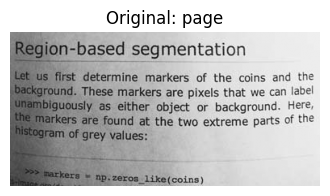

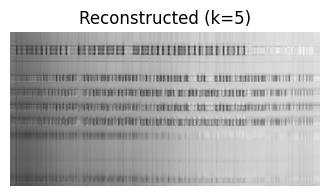

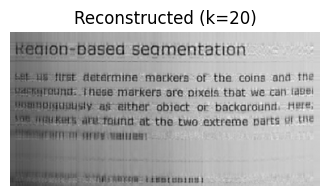

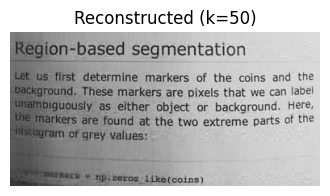

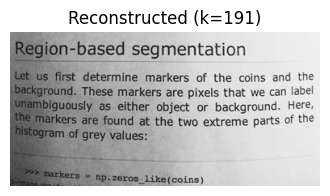

In [4]:
# ================== Main Execution ==================

k_values = [5, 10, 20, 30, 50, 75, 100, 150, 200]   # list of rank values to test (from heavy compression to near-original)
all_results = {}                                       # dictionary to store results for all images

print("\n🔧 Processing images...\n")   # notify user that processing has started

for name, img in dataset.items():     # iterate over each image in the dataset (name=image label, img=pixel array)

    img = img.astype(np.float64)      # convert pixel values to float64 for precise SVD calculations (avoids integer rounding)

    max_rank = min(img.shape)                           # maximum possible rank = smaller of (rows, columns) - SVD mathematical limit
    valid_k = [k for k in k_values if k <= max_rank]   # filter out k values that exceed the image's max rank (would cause errors)
    if max_rank not in valid_k:
        valid_k.append(max_rank)      # always include max_rank as a reference point (near-perfect reconstruction)

    print(f"\n--- {name} ---")        # print image name as section header in output

    results = []                      # list to collect (k, compression_ratio, psnr) tuples for this image

    for k in valid_k:                              # loop over each valid rank value
        recon = svd_compress(img, k)               # compress and reconstruct image using top-k singular values
        cr = compression_ratio(img.shape, k)       # calculate how much smaller the compressed version is
        p = compute_psnr(img, recon)               # measure reconstruction quality in decibels (dB)

        results.append((k, cr, p))                 # store the trio of values for plotting later

        print(f"k={k:3d} | CR={cr:.2f} | PSNR={p:.2f} dB")   # print formatted results: k value, compression ratio, quality score

    all_results[name] = results        # save this image's full results into the master dictionary

    # Display images
    display_image(img, title=f'Original: {name}')   # show the original uncompressed image

    for k_sample in [5, 20, 50, max_rank]:          # pick a few representative k values to visualize
        if k_sample in valid_k:                     # only display if this k value was actually computed
            recon = svd_compress(img, k_sample)     # recompute the reconstruction for this specific k
            display_image(recon, title=f'Reconstructed (k={k_sample})')   # display reconstructed image with k in title


📊 Plotting...


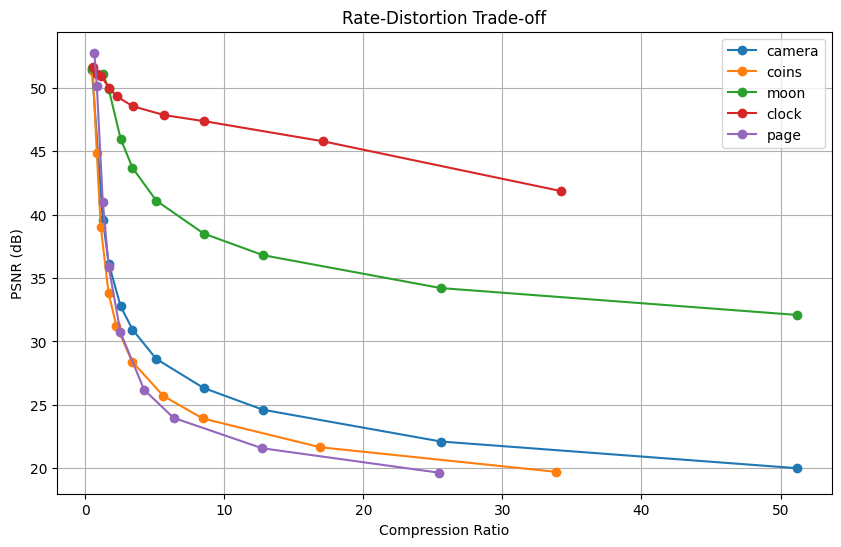

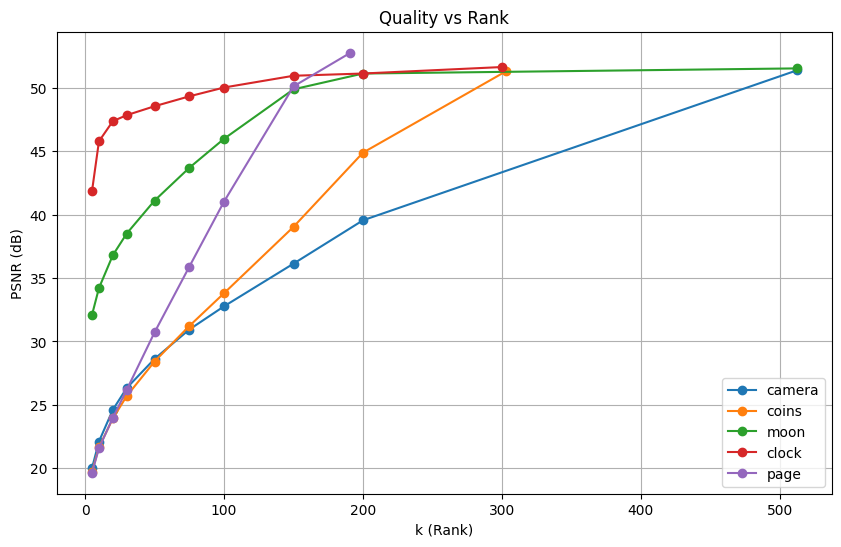

In [5]:
# ================== Plot Results ==================

print("\n📊 Plotting...")   # notify user that plotting phase has started

# --- First Plot: Compression Ratio vs PSNR (Rate-Distortion Curve) ---
plt.figure(figsize=(10, 6))                      # create a wide figure (10x6 inches) for the first plot
for name, res in all_results.items():            # loop over each image's stored results
    k_vals, cr_vals, psnr_vals = zip(*res)       # unpack list of tuples into three separate tuples
    plt.plot(cr_vals, psnr_vals, 'o-', label=name)  # plot CR on x-axis vs PSNR on y-axis with dots and lines

plt.xlabel('Compression Ratio')    # label x-axis: how compressed the image is (higher = more compressed)
plt.ylabel('PSNR (dB)')            # label y-axis: quality score in decibels (higher = better quality)
plt.title('Rate-Distortion Trade-off')   # title explaining what this plot shows
plt.legend()                       # show legend to identify which line belongs to which image
plt.grid()                         # add grid lines for easier reading of values
plt.show()                         # render and display the first plot

# --- Second Plot: Rank (k) vs PSNR ---
plt.figure(figsize=(10, 6))                      # create another wide figure for the second plot
for name, res in all_results.items():            # loop over each image's stored results again
    k_vals, cr_vals, psnr_vals = zip(*res)       # unpack results the same way
    plt.plot(k_vals, psnr_vals, 'o-', label=name)   # plot k on x-axis vs PSNR on y-axis

plt.xlabel('k (Rank)')             # label x-axis: number of singular values kept (higher = less compression)
plt.ylabel('PSNR (dB)')            # label y-axis: same quality metric as before
plt.title('Quality vs Rank')       # title: how quality improves as we increase the rank
plt.legend()                       # show legend for all 5 image curves
plt.grid()                         # add grid lines
plt.show()                         # render and display the second plot